# Handwritten digits

In [7]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [8]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [24]:
print(digits.data.shape)
n_samples, n_features = digits.data.shape
print(n_samples, n_features)

(1797, 64)
1797 64


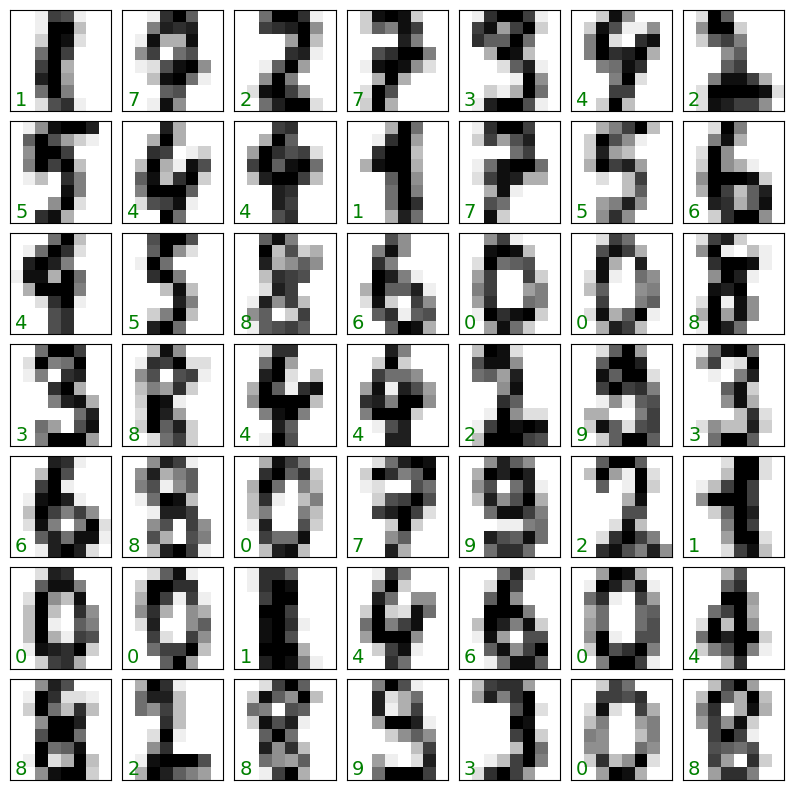

In [9]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [10]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


## Tasks. Part 1. Unsupervised Learning: Dimensionality Reduction on Digits

In [12]:
X, y = digits.data, digits.target
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


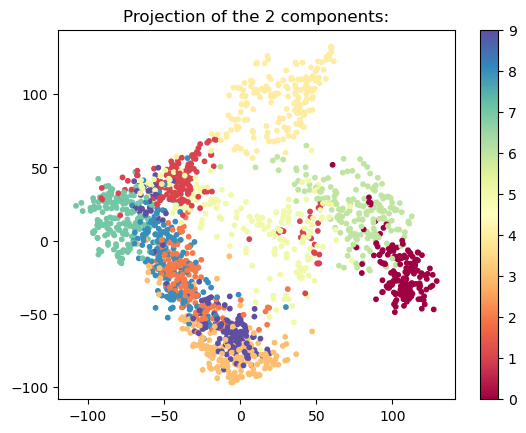

In [60]:
from sklearn.manifold import Isomap
embedding = Isomap(n_neighbors=10, n_components=2)

X_transformed = embedding.fit_transform(X)

plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c = y, s = 10, cmap=plt.cm.Spectral)
plt.title("Projection of the 2 components:")
plt.colorbar()
plt.show()

In [61]:
X, y = digits.data, digits.target
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


Reduced dataset shape: (1797, 2)
Projection of the 2 components:


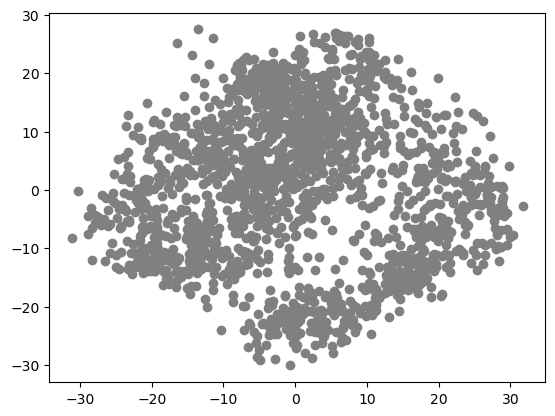

In [63]:
X_reduced = pca.transform(X)
print("Reduced dataset shape:", X_reduced.shape)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c='gray')

print("Projection of the 2 components:")
#for component in pca.components_:
#    print(" + ".join("%.3f x %s" % (value, name) for value, name in 
#                     zip(component, digits.feature_names)))

## Tasks. Part 2. Supervised Learning: Classification on Digits

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.metrics import confusion_matrix

clf = LogisticRegression(solver='sag', random_state=0).fit(X_train, y_train)

ypred_train = clf.predict(X_train)
print(confusion_matrix(y_train, ypred_train))

[[145   0   0   0   0   0   0   0   0   0]
 [  0 154   0   0   0   0   0   0   0   0]
 [  0   0 144   0   0   0   0   0   0   0]
 [  0   0   0 149   0   0   0   0   0   0]
 [  0   0   0   0 135   0   0   0   0   0]
 [  0   0   0   0   0 135   0   0   0   0]
 [  0   0   0   0   0   0 146   0   0   0]
 [  0   0   0   0   0   0   0 145   0   0]
 [  0   0   0   0   0   0   0   0 144   0]
 [  0   0   0   0   0   0   0   0   0 140]]


C:\Users\utente\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [54]:
ypred_test = clf.predict(X_test)
print(confusion_matrix(y_test, ypred_test))

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 44  0  1  0  0  0]
 [ 0  0  1  0  0 44  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


In [55]:
#accuracy of training set

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_train, ypred_train)
print(f"L'accuratezza del modello è: {accuracy:.2%}")

L'accuratezza del modello è: 100.00%


In [56]:
#accuracy of validation set

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, ypred_test)
print(f"L'accuratezza del modello è: {accuracy:.2%}")

L'accuratezza del modello è: 96.94%


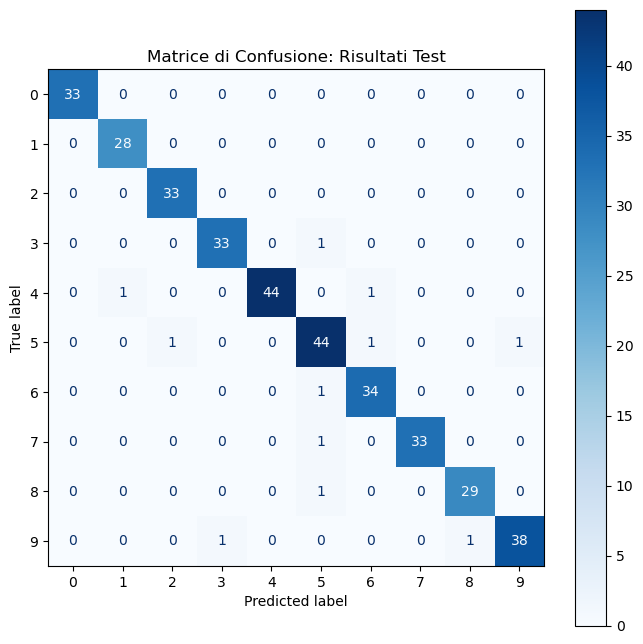

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ypred_test)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrice di Confusione: Risultati Test")
plt.show()